In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import gseapy as gp
from gseapy import barplot, dotplot

In [2]:
gp.__version__

'1.1.4'

In [3]:
def read_gene_list(gene_file):
    with open(gene_file, 'r') as fh:
        gene_list = [x.rstrip() for x in fh.readlines()]
    return gene_list

In [4]:
# grp1 = read_gene_list('/project/yangili1/cfbuenabadn/splice-pub/gofig/plot-fig2-heatmap-5groups-grp1_genes.txt')
# grp2 = read_gene_list('/project/yangili1/cfbuenabadn/splice-pub/gofig/plot-fig2-heatmap-5groups-grp2_genes.txt')
# grp3 = read_gene_list('/project/yangili1/cfbuenabadn/splice-pub/gofig/plot-fig2-heatmap-5groups-grp3_genes.txt')
# grp4 = read_gene_list('/project/yangili1/cfbuenabadn/splice-pub/gofig/plot-fig2-heatmap-5groups-grp4_genes.txt')
# grp5 = read_gene_list('/project/yangili1/cfbuenabadn/splice-pub/gofig/plot-fig2-heatmap-5groups-grp5_genes.txt')
bg = read_gene_list('/project/yangili1/cfbuenabadn/splice-pub/gofig/background_genes.txt')

In [6]:
# up_clusters = pd.read_csv('UP_clusters.tsv', sep='\t')

In [7]:
# genes_df = pd.read_csv('../code/resources/all_genes.protein_coding.bed.gz', sep='\t', 
#                        names = ['chrom', 'start', 'end', 'gene_id', 'gene_name', 'strand'])


# grp = grp1 + grp2 + grp3 + grp4 + grp5
# grp = sorted(set(grp))

# bg_names = list(genes_df.loc[genes_df.gene_id.isin(bg)].gene_name)

In [39]:
# Written by Figure2/Figure2_heatmap.ipynb (write_up_clusters), so the k-means
# groups here are exactly the ones drawn in Fig. 2c.
# NOTE: the stale copy at analysis/UP_clusters.tsv names this column
# `kcluster`, so the `.Cluster` references below fail against it.
up_psi_filter = pd.read_csv('Figure2/figure_data/UP_clusters.tsv', sep='\t')
up_psi_filter['gene'] = up_psi_filter.gene_id.apply(lambda x: x.split('.')[0])

def read_gene_list(gene_file):
    with open(gene_file, 'r') as fh:
        gene_list = [x.rstrip() for x in fh.readlines()]
    return gene_list

bg = read_gene_list('/project/yangili1/cfbuenabadn/splice-pub/gofig/background_genes.txt')
genes_df = pd.read_csv('../code/resources/all_genes.protein_coding.bed.gz', sep='\t', 
                       names = ['chrom', 'start', 'end', 'gene_id', 'gene_name', 'strand'])




In [48]:
up_psi_filter.loc[up_psi_filter.Cluster == 4, 'Testis'].median()

np.float64(5.273898627434316)

In [61]:
up_psi_filter.loc[up_psi_filter.Cluster == 6, 'Brain - Cortex'].mean()

np.float64(1.0805987587935053)

In [62]:
# Brain genes
grp = up_psi_filter.loc[up_psi_filter.Cluster.isin((5,6))].gene.unique()
grp = sorted(set(grp))

ad_gene_names = list(genes_df.loc[genes_df.gene_id.isin(grp)].gene_name)
bg_names = list(genes_df.loc[(genes_df.gene_id.isin(bg) | (genes_df.gene_id.isin(up_psi_filter.gene.unique()))) & (~genes_df.gene_id.isin(grp))].gene_name)

# Testis genes

grp = up_psi_filter.loc[up_psi_filter.Cluster==4].gene.unique()
grp = sorted(set(grp))

ad_gene_names_3 = list(genes_df.loc[genes_df.gene_id.isin(grp)].gene_name)
bg_names_3 = list(genes_df.loc[(genes_df.gene_id.isin(bg) | (genes_df.gene_id.isin(up_psi_filter.gene.unique()))) & (~genes_df.gene_id.isin(grp))].gene_name)

# Other

grp = up_psi_filter.loc[up_psi_filter.Cluster.isin((1, 2, 3))].gene.unique()
grp = sorted(set(grp))

ad_gene_names_other = list(genes_df.loc[genes_df.gene_id.isin(grp)].gene_name)
bg_names_other = list(genes_df.loc[(genes_df.gene_id.isin(bg) | (genes_df.gene_id.isin(up_psi_filter.gene.unique()))) & (~genes_df.gene_id.isin(grp))].gene_name)


In [75]:
import warnings
warnings.filterwarnings("ignore")


# gene_list = list(top_genes.loc[top_genes.resid > top_genes.resid.quantile(0.75)].symbol)

enr_brain = gp.enrich(gene_list=ad_gene_names, # or gene_list=glist
                 gene_sets=['../code/resources/MSigDB/c5.go.bp.v2023.1.Hs.symbols.gmt'], # kegg is a dict object
                 background=None, #"hsapiens_gene_ensembl",
                 outdir=None,
                 verbose=True)

enr_3 = gp.enrich(gene_list=ad_gene_names_3, # or gene_list=glist
                 gene_sets=['../code/resources/MSigDB/c5.go.bp.v2023.1.Hs.symbols.gmt'], # kegg is a dict object
                 background=None, #"hsapiens_gene_ensembl",
                 outdir=None,
                 verbose=True)

enr_other = gp.enrich(gene_list=ad_gene_names_other, # or gene_list=glist
                 gene_sets=['../code/resources/MSigDB/c5.go.bp.v2023.1.Hs.symbols.gmt'], # kegg is a dict object
                 background=None, #"hsapiens_gene_ensembl",
                 outdir=None,
                 verbose=True)

# dp = dotplot(enr2.res2d, title='Top AD affected genes',cmap='viridis', size=8, figsize=(3,5))

2025-03-27 12:16:48,684 [INFO] User defined gene sets is given: ../code/resources/MSigDB/c5.go.bp.v2023.1.Hs.symbols.gmt
2025-03-27 12:16:48,768 [INFO] Run: c5.go.bp.v2023.1.Hs.symbols.gmt 
2025-03-27 12:16:53,474 [INFO] Background is not set! Use all 17890 genes in c5.go.bp.v2023.1.Hs.symbols.gmt.
2025-03-27 12:16:54,754 [INFO] Done.
2025-03-27 12:16:54,768 [INFO] User defined gene sets is given: ../code/resources/MSigDB/c5.go.bp.v2023.1.Hs.symbols.gmt
2025-03-27 12:16:54,842 [INFO] Run: c5.go.bp.v2023.1.Hs.symbols.gmt 
2025-03-27 12:16:59,014 [INFO] Background is not set! Use all 17890 genes in c5.go.bp.v2023.1.Hs.symbols.gmt.
2025-03-27 12:16:59,939 [INFO] Done.
2025-03-27 12:16:59,953 [INFO] User defined gene sets is given: ../code/resources/MSigDB/c5.go.bp.v2023.1.Hs.symbols.gmt
2025-03-27 12:17:00,034 [INFO] Run: c5.go.bp.v2023.1.Hs.symbols.gmt 
2025-03-27 12:17:04,208 [INFO] Background is not set! Use all 17890 genes in c5.go.bp.v2023.1.Hs.symbols.gmt.
2025-03-27 12:17:05,705 [I

In [67]:
import warnings
warnings.filterwarnings("ignore")


test_list = list(ad_gene_names) + list(ad_gene_names_3) + list(ad_gene_names_other)
test_list = sorted(set(test_list))

enr = gp.enrich(gene_list=test_list, # or gene_list=glist
                 gene_sets=['../code/resources/MSigDB/c5.go.bp.v2023.1.Hs.symbols.gmt'], # kegg is a dict object
                 background=None, #"hsapiens_gene_ensembl",
                 outdir=None,
                 verbose=True)


# dp = dotplot(enr2.res2d, title='Top AD affected genes',cmap='viridis', size=8, figsize=(3,5))

2025-03-27 12:15:26,600 [INFO] User defined gene sets is given: ../code/resources/MSigDB/c5.go.bp.v2023.1.Hs.symbols.gmt
2025-03-27 12:15:26,679 [INFO] Run: c5.go.bp.v2023.1.Hs.symbols.gmt 
2025-03-27 12:15:30,937 [INFO] Background is not set! Use all 17890 genes in c5.go.bp.v2023.1.Hs.symbols.gmt.
2025-03-27 12:15:32,583 [INFO] Done.


In [41]:
# barplot(enr.results,
#               column="P-value",
#               group='cluster', # set group, so you could do a multi-sample/library comparsion
#               size=50,
#               top_term=15,
#               figsize=(3,5), width=2# set colors for group
# #               color = {'KEGG_2021_Human': 'salmon', 'MSigDB_Hallmark_2020':'darkblue'}
#              )

In [131]:
enr_brain.results['cluster'] = 'Brain'
enr_3.results['cluster'] = 'Testis'
enr_other.results['cluster'] = 'Other tissues'


enr_brain.results['cluster_id'] = 'Groups I/II (Brain)'
enr_3.results['cluster_id'] = 'Group VI (Testis)'
enr_other.results['cluster_id'] = 'Groups III/IV/V (Other tissues)'


enr = pd.concat([enr_brain.results, enr_3.results, enr_other.results])

<Axes: xlabel='$- \\log_{10}$ (P-value)'>

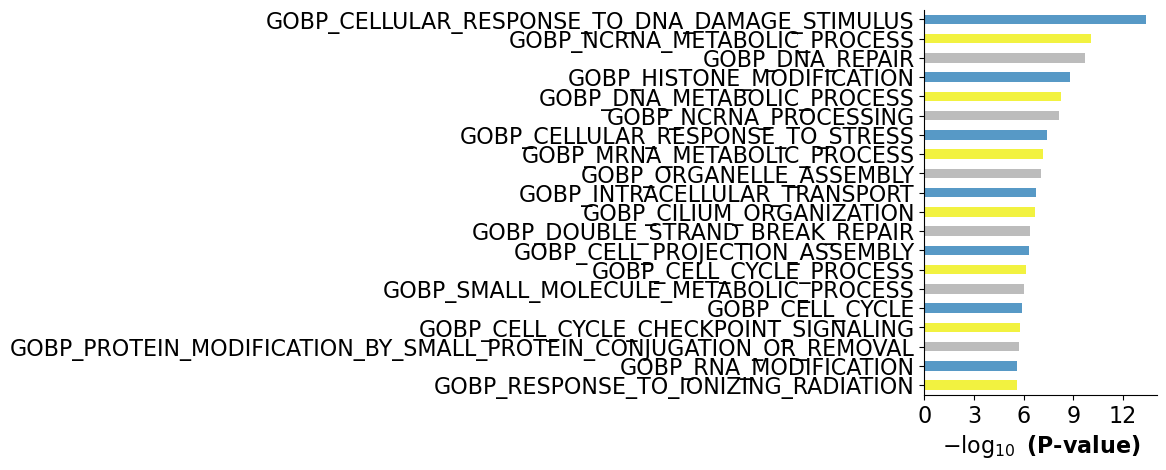

In [70]:
barplot(enr.results,
              column="P-value",
              group='cluster', # set group, so you could do a multi-sample/library comparsion
              size=50,
              top_term=20,
              figsize=(3,5), width=2,
        color=['#EEEE00', '#1f77b4', '#A6A6A6']# set colors for group
#               color = {'KEGG_2021_Human': 'salmon', 'MSigDB_Hallmark_2020':'darkblue'}
             )

In [132]:
enr['genes_in_signature'] = enr.Overlap.apply(lambda x: int(x.split('/')[1]))

In [85]:
enr.loc[enr.Term == 'GOBP_CELLULAR_RESPONSE_TO_DNA_DAMAGE_STIMULUS']

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes,cluster,cluster_id
355,c5.go.bp.v2023.1.Hs.symbols.gmt,GOBP_CELLULAR_RESPONSE_TO_DNA_DAMAGE_STIMULUS,66/868,4.464631e-06,3.930661e-03,1.925146,23.716501,RAD1;REV3L;ALKBH8;SUPT20H;XPA;BOD1L1;RAD51AP1;...,Brain,groups I/II
246,c5.go.bp.v2023.1.Hs.symbols.gmt,GOBP_CELLULAR_RESPONSE_TO_DNA_DAMAGE_STIMULUS,23/868,4.815960e-02,6.318477e-01,1.526034,4.628820,XPA;HMGN1;PIDD1;FOXN3;DCLRE1C;FTO;ZMPSTE24;POL...,Testis,group VI
425,c5.go.bp.v2023.1.Hs.symbols.gmt,GOBP_CELLULAR_RESPONSE_TO_DNA_DAMAGE_STIMULUS,108/868,5.967689e-11,3.131843e-07,2.136692,50.302165,RAD1;ATR;TELO2;RAD51AP1;BOD1L1;POLM;HUS1;HMGN1...,Other tissues,groups III/IV/V


In [79]:
enr.loc[enr.Term == 'GOBP_NCRNA_METABOLIC_PROCESS']

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes,cluster
1637,c5.go.bp.v2023.1.Hs.symbols.gmt,GOBP_NCRNA_METABOLIC_PROCESS,55/613,1.947717e-07,0.000856,2.307035,35.647005,PDCD11;THUMPD2;OSGEP;TENT2;ALKBH8;ERI2;NSUN3;T...,Brain
1107,c5.go.bp.v2023.1.Hs.symbols.gmt,GOBP_NCRNA_METABOLIC_PROCESS,15/613,1.554834e-01,0.690859,1.405996,2.616864,RIOK1;FBL;NSUN3;TRMT11;TRDMT1;DTWD1;ALKBH1;MET...,Testis
1925,c5.go.bp.v2023.1.Hs.symbols.gmt,GOBP_NCRNA_METABOLIC_PROCESS,70/613,3.815329e-06,0.001669,1.901289,23.721399,THUMPD2;OSGEP;DDX17;CC2D1A;NOL8;TAF1B;TCOF1;PO...,Other tissues


In [133]:
enr_final = enr.loc[(enr['Combined Score'] > 20) & (enr.genes_in_signature >= 50) & (enr['Adjusted P-value'] <= 0.01)].sort_values('Combined Score', ascending=False)[
    ['Term', 'Overlap', 'P-value', 'Adjusted P-value', 'Odds Ratio', 'Combined Score', 'Genes', 'cluster', 'cluster_id']
].copy()

In [134]:
enr_final.Term = enr_final.Term.apply(lambda x: ' '.join(x.split('_')))
# enr_final.Genes = enr_final.Genes.apply(lambda x: ', '.join(x.split(';')))

In [135]:
enr_final['Odds Ratio'] = enr_final['Odds Ratio'].apply(lambda x: f"{x:.2f}")
enr_final['P-value'] = enr_final['P-value'].apply(lambda x: f"{x:.2e}")
enr_final['Adjusted P-value'] = enr_final['Adjusted P-value'].apply(lambda x: f"{x:.2e}")
enr_final['Overlap'] = enr_final['Overlap'].apply(lambda x: ' / '.join(x.split('/')))

In [137]:
enr_final.to_csv('enrichment_clusters.csv', header=True, index=False)

In [99]:
enr.loc[(enr['Combined Score'] > 30) & (enr.genes_in_signature >= 50) & (enr['Adjusted P-value'] <= 0.1)].shape

(19, 11)

In [136]:
enr_final.shape

(28, 9)

In [45]:
enr.to_csv('C5.go.bp.results.tsv.gz', sep='\t', header=True, index=False)

<Axes: xlabel='$- \\log_{10}$ (P-value)'>

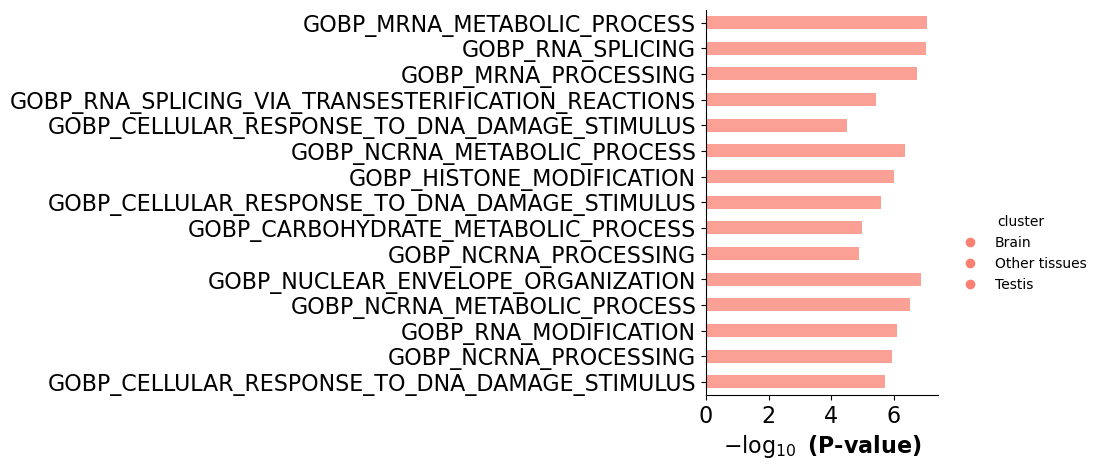

In [28]:
barplot(enr,
              column="P-value",
              group='cluster', # set group, so you could do a multi-sample/library comparsion
              size=50,
              top_term=5,
              figsize=(3,5), width=2# set colors for group
#               color = {'KEGG_2021_Human': 'salmon', 'MSigDB_Hallmark_2020':'darkblue'}
             )

In [ ]:
enr.to_csv('C5.ALL.results.tsv.gz', sep='\t', header=True, index=False)

In [10]:
enr.to_csv('C5.ALL.results.tsv.gz', sep='\t', header=True, index=False)

In [12]:
enr.sort_values('Combined Score')

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes,cluster
5993,c5.all.v2023.1.Hs.symbols.gmt,GOMF_G_PROTEIN_COUPLED_RECEPTOR_ACTIVITY,1/845,1.000000,1.000000,0.027771,-0.000000e+00,CRCP,Other tissues
1152,c5.all.v2023.1.Hs.symbols.gmt,GOBP_G_PROTEIN_COUPLED_RECEPTOR_SIGNALING_PATHWAY,16/1274,1.000000,1.000000,0.202851,-0.000000e+00,PLPP1;ACTN2;ARRB2;ARHGEF11;DGKQ;DGKA;ROCK1;GRK...,Other tissues
5486,c5.all.v2023.1.Hs.symbols.gmt,GOMF_G_PROTEIN_COUPLED_RECEPTOR_ACTIVITY,1/845,1.000000,1.000000,0.037404,-0.000000e+00,OPN3,Brain
1043,c5.all.v2023.1.Hs.symbols.gmt,GOBP_G_PROTEIN_COUPLED_RECEPTOR_SIGNALING_PATHWAY,10/1274,1.000000,1.000000,0.172560,2.682117e-16,YWHAB;PPP1R9B;ARHGEF11;OPN3;PRKCA;GRK3;FLNA;RG...,Brain
4549,c5.all.v2023.1.Hs.symbols.gmt,GOBP_SENSORY_PERCEPTION_OF_CHEMICAL_STIMULUS,1/536,1.000000,1.000000,0.044573,4.552697e-16,PLCB2,Other tissues
...,...,...,...,...,...,...,...,...,...
5231,c5.all.v2023.1.Hs.symbols.gmt,GOMF_AMINO_ACID_MONOATOMIC_CATION_ANTIPORTER_A...,3/5,0.000762,0.059805,30.957782,2.222621e+02,SLC25A12;SLC38A5;SLC25A13,Brain
9429,c5.all.v2023.1.Hs.symbols.gmt,HP_SUBRETINAL_DEPOSITS,3/5,0.000762,0.059805,30.957782,2.222621e+02,CSPP1;CYP4V2;KIAA0586,Brain
9239,c5.all.v2023.1.Hs.symbols.gmt,HP_SEA_BLUE_HISTIOCYTOSIS,3/5,0.000762,0.059805,30.957782,2.222621e+02,NPC1;SMPD1;GLB1,Brain
6064,c5.all.v2023.1.Hs.symbols.gmt,HP_BROAD_JAW,3/6,0.000442,0.053228,33.948602,2.621967e+02,SH3BP2;LRP5;SNIP1,Testis


In [12]:
# enr.to_csv('C5.GO_BP.results.tsv.gz', sep='\t', header=True, index=False)

In [17]:
enr_3.results.sort_values('Adjusted P-value')

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes,cluster
2480,c5.all.v2023.1.Hs.symbols.gmt,GOBP_TELOMERIC_D_LOOP_DISASSEMBLY,3/9,0.000202,0.196616,39.056342,332.281247,SLX1A;POT1;BLM,Testis
671,c5.all.v2023.1.Hs.symbols.gmt,GOBP_IMMUNOGLOBULIN_V_D_J_RECOMBINATION,3/8,0.000136,0.196616,46.159910,410.962136,CYREN;XRCC4;NHEJ1,Testis
161,c5.all.v2023.1.Hs.symbols.gmt,GOBP_CALCIUM_ION_TRANSMEMBRANE_TRANSPORT_VIA_H...,4/19,0.000114,0.196616,21.128295,191.786783,CACNB1;CACNB3;UBR3;SESTD1,Testis
2837,c5.all.v2023.1.Hs.symbols.gmt,GOCC_NONHOMOLOGOUS_END_JOINING_COMPLEX,3/9,0.000202,0.196616,39.056342,332.281247,XRCC5;XRCC4;NHEJ1,Testis
3464,c5.all.v2023.1.Hs.symbols.gmt,GOMF_TELOMERIC_DNA_BINDING,5/38,0.000162,0.196616,11.982563,104.551774,POT1;BLM;UPF3A;XRCC5;SMG6,Testis
...,...,...,...,...,...,...,...,...,...
1130,c5.all.v2023.1.Hs.symbols.gmt,GOBP_NEGATIVE_REGULATION_OF_RESPONSE_TO_EXTERN...,1/446,0.998040,0.999995,0.236813,0.000465,CARD8,Testis
2660,c5.all.v2023.1.Hs.symbols.gmt,GOCC_CELL_SURFACE,2/929,0.999972,0.999995,0.185383,0.000005,CD59;MPZL1,Testis
2905,c5.all.v2023.1.Hs.symbols.gmt,GOCC_RECEPTOR_COMPLEX,1/527,0.999378,0.999995,0.199511,0.000124,BMAL1,Testis
1168,c5.all.v2023.1.Hs.symbols.gmt,GOBP_NERVOUS_SYSTEM_PROCESS,7/1538,0.999934,0.999995,0.331903,0.000022,CNNM4;ADARB1;UBR3;RGS14;SPATA7;PLCB2;MGLL,Testis


IndexError: list index out of range

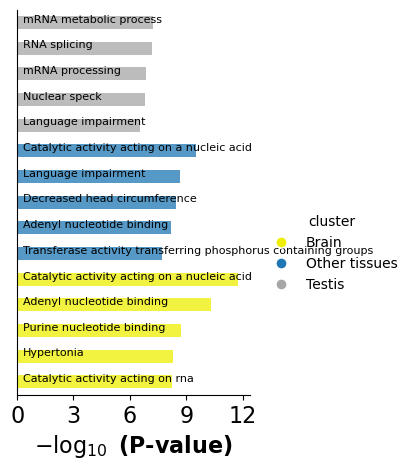

In [13]:
import re
ax = barplot(enr,
              column="P-value",
              group='cluster', # set group, so you could do a multi-sample/library comparsion
              size=50,
              top_term=5,
              figsize=(3,5), width=2,
              color=['#EEEE00', '#1f77b4', '#A6A6A6'] # set colors for group
#               color = {'KEGG_2021_Human': 'salmon', 'MSigDB_Hallmark_2020':'darkblue'}
             )

yticks = ax.get_yticklabels()
ax.set_yticks([])

for i in range(30):
    new_text = re.sub('Mrna', 'mRNA', 
       re.sub('mrna', 'mRNA', re.sub('Rna', 'RNA', ' '.join(str(yticks[i]).split("'")[1].split('_')[1:]).capitalize())))
    
    ax.text(0.3, i, new_text, fontsize=8)

In [338]:
import re
re.sub('Mrna', 'mRNA', 
       re.sub('mrna', 'mRNA', re.sub('Rna', 'RNA', ' '.join(str(yticks[3]).split("'")[1].split('_')[1:]).capitalize())))

'mRNA metabolic process'

In [310]:
yticks

[Text(0, 0, 'GOMF_RNA_BINDING'),
 Text(0, 1, 'GOMF_ADENYL_NUCLEOTIDE_BINDING'),
 Text(0, 2, 'GOMF_CATALYTIC_ACTIVITY_ACTING_ON_A_NUCLEIC_ACID'),
 Text(0, 3, 'GOBP_MRNA_METABOLIC_PROCESS'),
 Text(0, 4, 'GOBP_RNA_SPLICING_VIA_TRANSESTERIFICATION_REACTIONS'),
 Text(0, 5, 'GOCC_NUCLEAR_SPECK'),
 Text(0, 6, 'GOCC_MITOCHONDRION'),
 Text(0, 7, 'GOBP_MRNA_PROCESSING'),
 Text(0, 8, 'GOCC_NUCLEAR_BODY'),
 Text(0, 9, 'GOBP_RNA_SPLICING'),
 Text(0, 10, 'HP_DECREASED_HEAD_CIRCUMFERENCE'),
 Text(0, 11, 'GOCC_MICROTUBULE_ORGANIZING_CENTER'),
 Text(0, 12, 'HP_ATROPHY_DEGENERATION_AFFECTING_THE_CENTRAL_NERVOUS_SYSTEM'),
 Text(0, 13, 'GOMF_ADENYL_NUCLEOTIDE_BINDING'),
 Text(0, 14, 'GOBP_NCRNA_METABOLIC_PROCESS'),
 Text(0, 15, 'HP_HYPERTONIA'),
 Text(0, 16, 'GOBP_NCRNA_PROCESSING'),
 Text(0, 17, 'HP_ABNORMAL_HINDBRAIN_MORPHOLOGY'),
 Text(0, 18, 'GOMF_CATALYTIC_ACTIVITY_ACTING_ON_A_NUCLEIC_ACID'),
 Text(0, 19, 'GOCC_MITOCHONDRION'),
 Text(0, 20, 'HP_MALAR_RASH'),
 Text(0, 21, 'GOMF_DAMAGED_DNA_BINDING'),


In [224]:
data = enr2.res2d.loc[enr2.res2d['Adjusted P-value']<0.01].sort_values('Adjusted P-value', ascending=True).iloc[:5][['Term', 'P-value']]

In [225]:
import matplotlib.colors as mcolors

In [226]:
data.Term.iloc[4]

'GOBP_CELLULAR_RESPONSE_TO_DNA_DAMAGE_STIMULUS'

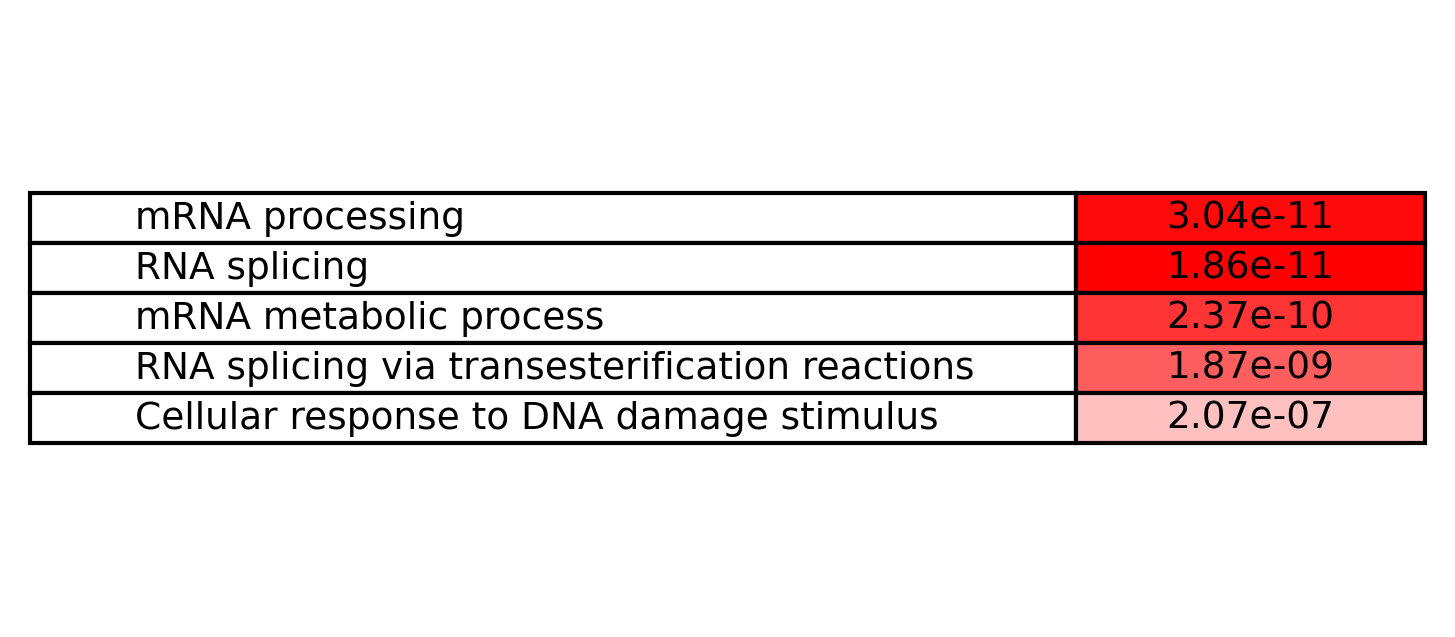

In [227]:
df = pd.DataFrame(data)
df['Term'] = ['mRNA processing', 'RNA splicing', 'mRNA metabolic process', 'RNA splicing via transesterification reactions',
             'Cellular response to DNA damage stimulus']

# Compute -log10 of Adjusted P-values
df["-log10(P-value)"] = -np.log10(df["P-value"])

# Normalize for color

# Normalize for colormap
norm = mcolors.Normalize(vmin=0, vmax=df["-log10(P-value)"].max())
cmap = plt.cm.bwr

vmax = vmax=df["-log10(P-value)"].max()

# Plot table
fig, ax = plt.subplots(figsize=(6, len(df) * 0.5), dpi=300)
ax.set_axis_off()

table_data = []
cell_colors = []

for term, pval, logpval in zip(df["Term"], df["P-value"], df["-log10(P-value)"]):
    table_data.append([term, f"{pval:.2e}"])
    cell_colors.append(["white", cmap(norm(logpval))])  # White for text column, colored for values

# Create table without column headers
table = plt.table(
    cellText=table_data,
    cellLoc="center",
    cellColours=cell_colors,
    colWidths=[0.75, 0.25],  # First column is 3x wider than second
    loc="center",
)

# Align the first column text to the left
for i in range(len(df)):
    table[(i, 0)].set_text_props(ha="left")

plt.savefig('../code/plots/fig2_GO_brain.png', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig2_GO_brain.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig2_GO_brain.svg', dpi=300, bbox_inches='tight')

In [228]:
grp = up_psi_filter.loc[up_psi_filter.Cluster.isin((3, 4, 5, 6))].gene.unique()
grp = sorted(set(grp))

ad_gene_names = list(genes_df.loc[genes_df.gene_id.isin(grp)].gene_name)
bg_names = list(genes_df.loc[genes_df.gene_id.isin(bg) & (~genes_df.gene_id.isin(grp))].gene_name)

enr2 = gp.enrich(gene_list=ad_gene_names, # or gene_list=glist
                 gene_sets=['../code/resources/MSigDB/c5.go.bp.v2023.1.Hs.symbols.gmt'], # kegg is a dict object
                 background=None, #"hsapiens_gene_ensembl",
                 outdir=None,
                 verbose=True)

data = enr2.res2d.loc[enr2.res2d['Adjusted P-value']<0.01].sort_values('P-value', ascending=True).iloc[:5]#[['Term', 'Adjusted P-value']]
data

2025-02-05 22:09:28,038 [INFO] User defined gene sets is given: ../code/resources/MSigDB/c5.go.bp.v2023.1.Hs.symbols.gmt
2025-02-05 22:09:28,131 [INFO] Run: c5.go.bp.v2023.1.Hs.symbols.gmt 
2025-02-05 22:09:32,321 [INFO] Background is not set! Use all 17890 genes in c5.go.bp.v2023.1.Hs.symbols.gmt.
2025-02-05 22:09:33,740 [INFO] Done.


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
1822,c5.go.bp.v2023.1.Hs.symbols.gmt,GOBP_NCRNA_METABOLIC_PROCESS,80/613,4.730089e-10,0.000002,2.323797,49.896359,SIRT7;THUMPD2;NVL;PUS7;OSGEP;TOE1;TAF1B;LARP7;...
1823,c5.go.bp.v2023.1.Hs.symbols.gmt,GOBP_NCRNA_PROCESSING,59/433,2.017599e-08,0.000051,2.422509,42.923887,SIRT7;THUMPD2;TSEN54;PTCD1;MTO1;MRM2;NVL;UTP4;...
1341,c5.go.bp.v2023.1.Hs.symbols.gmt,GOBP_INTRACELLULAR_TRANSPORT,149/1591,5.452635e-07,0.000913,1.612281,23.252316,EHD2;PEX19;RINT1;SIRT7;RHOT2;DENND5A;TBC1D17;Z...
783,c5.go.bp.v2023.1.Hs.symbols.gmt,GOBP_DNA_REPAIR,68/584,7.959347e-07,0.001000,2.021589,28.390692,XRCC4;DDX11;NABP1;FH;SIRT7;NPAS2;POLI;RAD1;HMG...
391,c5.go.bp.v2023.1.Hs.symbols.gmt,GOBP_CELLULAR_RESPONSE_TO_DNA_DAMAGE_STIMULUS,91/868,1.245113e-06,0.001056,1.803994,24.527609,RINT1;SIRT7;NPAS2;HMGN1;RAD51D;MLST8;TAF4;TDP1...


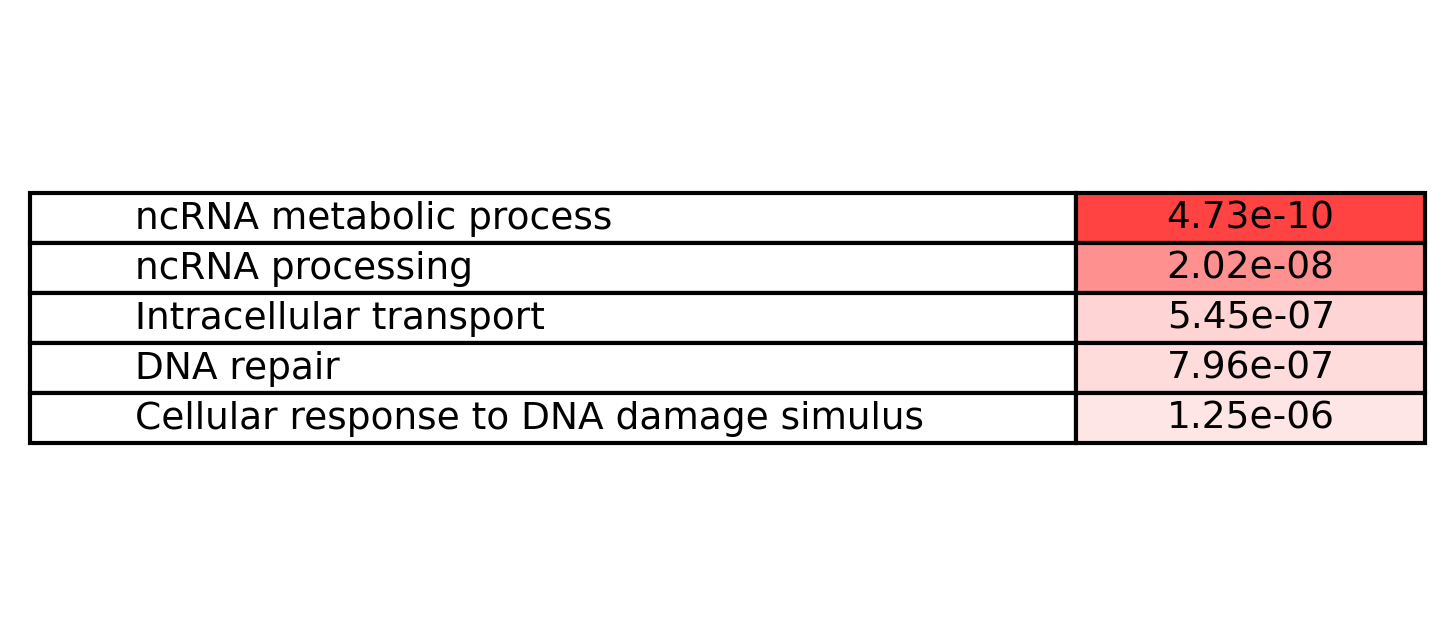

In [229]:
df = pd.DataFrame(data)
df['Term'] = ['ncRNA metabolic process', 'ncRNA processing', 'Intracellular transport', 'DNA repair', 'Cellular response to DNA damage simulus']

# Compute -log10 of Adjusted P-values
df["-log10(P-value)"] = -np.log10(df["P-value"])

# Normalize for color

# Normalize for colormap
norm = mcolors.Normalize(vmin=0, vmax=vmax)
cmap = plt.cm.bwr

# Plot table
fig, ax = plt.subplots(figsize=(6, len(df) * 0.5), dpi=300)
ax.set_axis_off()

table_data = []
cell_colors = []

for term, pval, logpval in zip(df["Term"], df["P-value"], df["-log10(P-value)"]):
    table_data.append([term, f"{pval:.2e}"])
    cell_colors.append(["white", cmap(norm(logpval))])  # White for text column, colored for values

# Create table without column headers
table = plt.table(
    cellText=table_data,
    cellLoc="center",
    cellColours=cell_colors,
    colWidths=[0.75, 0.25],  # First column is 3x wider than second
    loc="center",
)

# Align the first column text to the left
for i in range(len(df)):
    table[(i, 0)].set_text_props(ha="left")

plt.savefig('../code/plots/fig2_GO_other.png', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig2_GO_other.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig2_GO_other.svg', dpi=300, bbox_inches='tight')

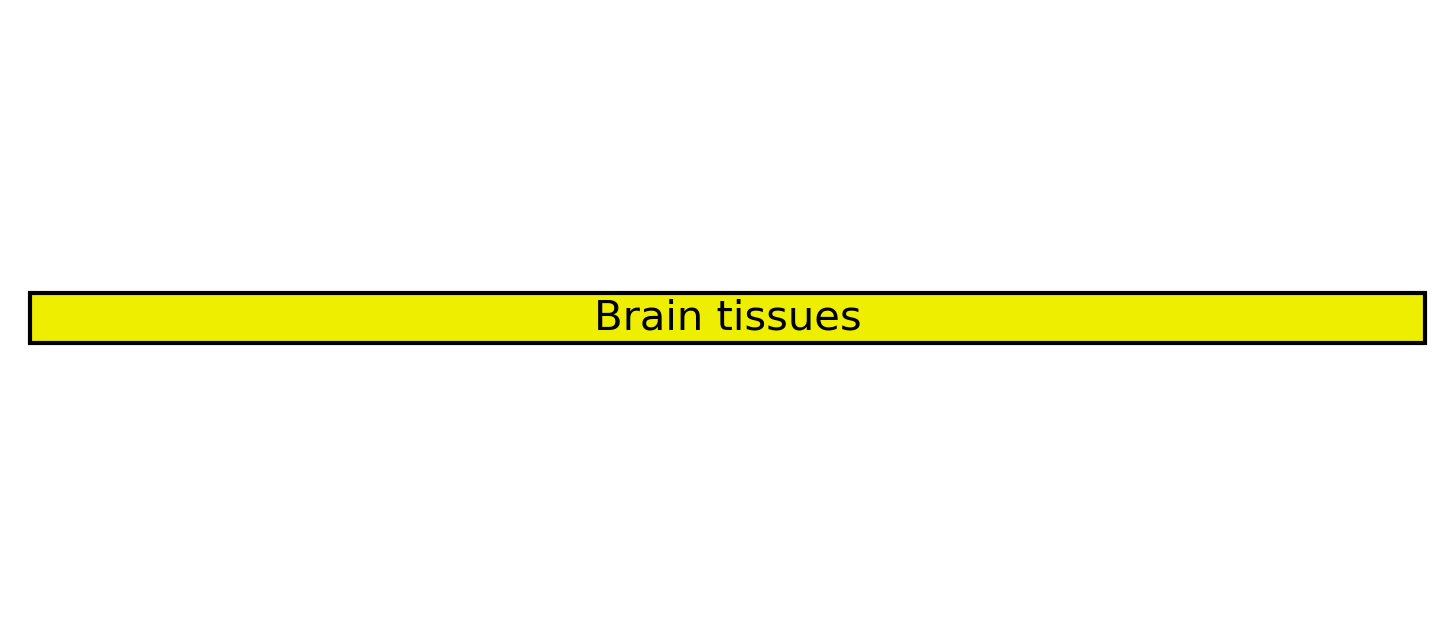

In [234]:
# Plot table
fig, ax = plt.subplots(figsize=(6, len(df) * 0.5), dpi=300)
ax.set_axis_off()


# Create table without column headers
table = plt.table(
    cellText=[['Brain tissues']],
    cellLoc="center",
    cellColours=[['#EEEE00']],
    loc="center",
)

plt.savefig('../code/plots/fig2_GO_brain_header.png', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig2_GO_brain_header.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig2_GO_brain_header.svg', dpi=300, bbox_inches='tight')

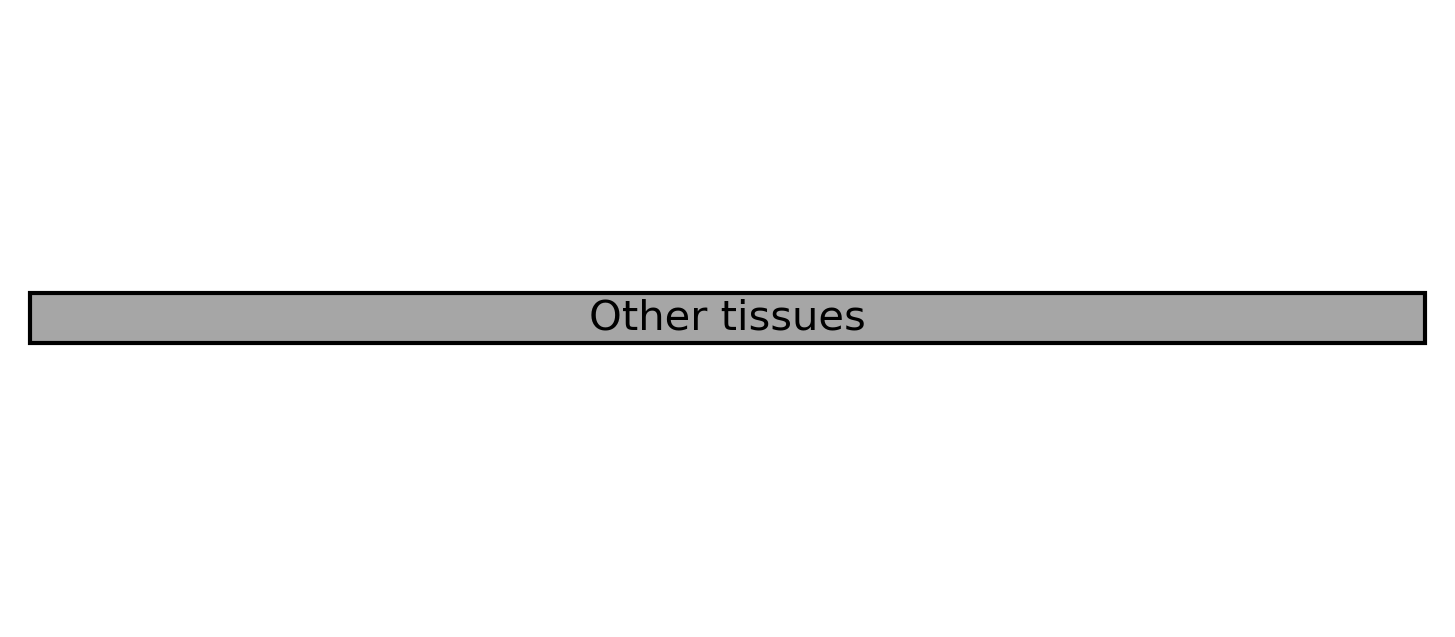

In [235]:
# Plot table
fig, ax = plt.subplots(figsize=(6, len(df) * 0.5), dpi=300)
ax.set_axis_off()


# Create table without column headers
table = plt.table(
    cellText=[['Other tissues']],
    cellLoc="center",
    cellColours=[['#A6A6A6']],
    loc="center",
)


plt.savefig('../code/plots/fig2_GO_other_header.png', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig2_GO_other_header.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig2_GO_other_header.svg', dpi=300, bbox_inches='tight')